In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv(r"C:\Users\Acer\Downloads\diabetes.csv")
df.head()
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
# Checking for imbalance in the data
class_counts = df['Outcome'].value_counts()
class_counts

Outcome
0    500
1    268
Name: count, dtype: int64

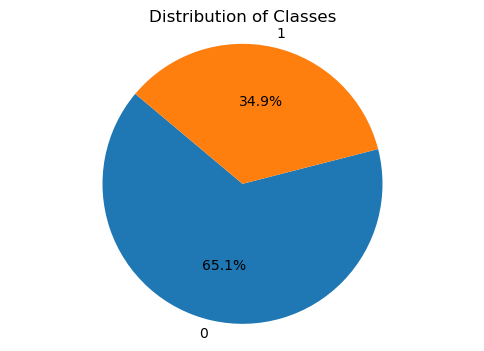

In [10]:
# Plotting a pie chart to check the imbalance class
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.pie(class_counts, labels= class_counts.index, autopct='%1.1f%%',startangle =140)
plt.axis('equal')
plt.title('Distribution of Classes')
plt.show()

In [12]:
# split dataset in features and target variables
feature_cols=['Pregnancies','Insulin','BMI','Age','Glucose','BloodPressure','DiabetesPedigreeFunction']
x=df[feature_cols]
y=df.Outcome

In [14]:
#scale the features
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x= sc.fit_transform(x)

In [16]:
# Split x and y into training and testing sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test =train_test_split(x, y, train_size = 0.70, test_size=0.30,random_state=25)

In [20]:
# apply SMOTE to balance dataset
from imblearn.over_sampling import SMOTE
# when sampling_strategy is set to 1 = majority class, 0 = minority class
smote = SMOTE(sampling_strategy=1.0, random_state =42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

In [22]:
#This is thebalance in the data only for the training set
print(y_train_resampled.value_counts())

Outcome
1    340
0    340
Name: count, dtype: int64


In [26]:
# Implementing the SVM model
from sklearn.svm import SVC
from sklearn.metrics import classification_report

svm_model = SVC(kernel ='linear', random_state = 42)
svm_model.fit(x_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred = svm_model.predict(x_test)

# Evaluate the model
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.78      0.82       160
           1       0.59      0.72      0.65        71

    accuracy                           0.76       231
   macro avg       0.73      0.75      0.73       231
weighted avg       0.78      0.76      0.77       231



In [34]:
# Implementing the SVM model
from sklearn.svm import SVC
from sklearn.metrics import classification_report

svm_model = SVC(kernel ='rbf', random_state = 42)
svm_model.fit(x_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred = svm_model.predict(x_test)

# Evaluate the model
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.74      0.80       160
           1       0.56      0.76      0.65        71

    accuracy                           0.74       231
   macro avg       0.72      0.75      0.72       231
weighted avg       0.78      0.74      0.75       231



In [40]:
# Implementing the SVM model
from sklearn.svm import SVC
from sklearn.metrics import classification_report

svm_model = SVC(kernel ='poly', random_state = 42)
svm_model.fit(x_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred = svm_model.predict(x_test)

# Evaluate the model
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       160
           1       0.66      0.54      0.59        71

    accuracy                           0.77       231
   macro avg       0.73      0.71      0.71       231
weighted avg       0.76      0.77      0.76       231



In [42]:
# Implementing the SVM model
from sklearn.svm import SVC
from sklearn.metrics import classification_report

svm_model = SVC(kernel ='sigmoid', random_state = 42)
svm_model.fit(x_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred = svm_model.predict(x_test)

# Evaluate the model
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.62      0.71       160
           1       0.44      0.68      0.54        71

    accuracy                           0.64       231
   macro avg       0.63      0.65      0.62       231
weighted avg       0.70      0.64      0.65       231



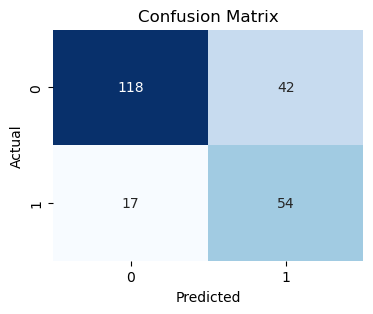

In [36]:
from sklearn import metrics
import seaborn as sns

#calculating the confusion matrix
cnf_matrix=metrics.confusion_matrix(y_test, y_pred)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(4,3))
sns.heatmap(cnf_matrix, cmap="Blues",  annot= True, fmt='g', cbar =False)

# Add labels and title
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

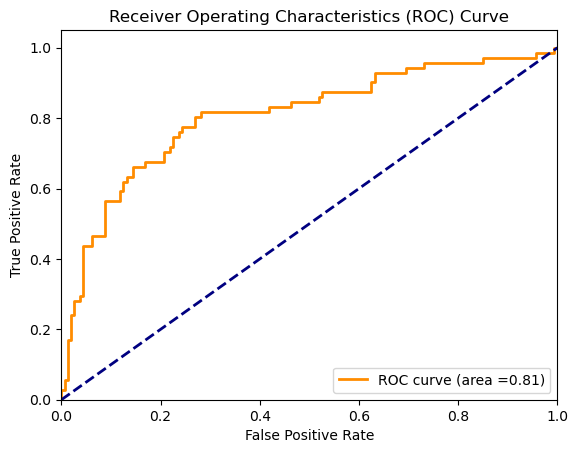

In [30]:
import numpy as np
from sklearn.metrics import roc_curve, auc

# Fit the logistic regression model
svm_model.fit(x_train_resampled, y_train_resampled)

# Predict probabilities for the positive class
y_prob = svm_model.decision_function(x_test)

# Compute ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc= auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area =%0.2f)' %roc_auc)
plt.plot([0,1],[0,1], color='navy',lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristics (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Additional work with IRIS dataset to get SVM visual with hyperplane
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets, metrics

# Load iris dataset and select only Setosa and Virginica classes
iris = datasets.load_iris()
x= iris.data[:,:2]
y= iris.target
x=x[(y==0)| (y==2)]
y=y[(y==0)| (y==2)]
y[y==2] = 1

# Fit SVM model
clf =svm.SVC(kernel= 'linear', C=10)
clf.fit(x,y)

# Compute accuracy, recall, and F1 score
y_pred = clf.predict(x)
accuracy = metrics.accuracy_score(y, y_pred)
recall = metrics.recall_score(y, y_pred)
f1_score = metrics.f1_score(y, y_pred)

# Print results
print("Accuracy:", accuracy)
print("Recall:", recall)
print("F1 score:", f1_score)

In [ ]:
# Plot support vectors and separating hyperplane
plt.scatter(x[:,0], x[:,1],c=y,cmap=plt.cm.Paired)
ax =plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx= np.linspace(xlim[0], xlim[1], 30)
yy= np.linspace(ylim[0], ylim[1], 30)
YY,XX=np.meshgrid(yy,xx)
xy=np.vstack([XX.ravel(), YY.ravel()]).T
Z= clf.decision_function(xy).reshape(XX.shape)
ax.contour(XX, YY, Z, colors ='k', levels=[-1,0,1], alpha =0.5, linestyles =['--','-','--'])
ax.scatter(clf.support_vectors_[:,0], clf.support_vectors_[:,1], s=100, linewidth =1, facecolors='none', edgecolors ='k')
plt.show()